In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

df_train = pd.read_csv('../data/KDDTrain.txt', names=col_names)
df_test = pd.read_csv('../data/KDDTest.txt', names=col_names)

df_train['is_train'] = 1
df_test['is_train'] = 0

df_all = pd.concat([df_train, df_test], ignore_index=True)

df_all.info()
df_all.head(5)


<class 'pandas.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     148517 non-null  int64  
 1   protocol_type                148517 non-null  str    
 2   service                      148517 non-null  str    
 3   flag                         148517 non-null  str    
 4   src_bytes                    148517 non-null  int64  
 5   dst_bytes                    148517 non-null  int64  
 6   land                         148517 non-null  int64  
 7   wrong_fragment               148517 non-null  int64  
 8   urgent                       148517 non-null  int64  
 9   hot                          148517 non-null  int64  
 10  num_failed_logins            148517 non-null  int64  
 11  logged_in                    148517 non-null  int64  
 12  num_compromised              148517 non-null  int64  
 13  root_shell

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level,is_train
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,1
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,1
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,1
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,1


In [2]:
columns_to_drop = ['difficulty_level', 'num_outbound_cmds']

df_all_cleaned = df_all.drop(columns=[col for col in columns_to_drop if col in df_all])


df_all_cleaned.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,is_train
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,1
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,1
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,1
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,1


In [3]:
df_all_cleaned.dtypes
#protocol_type, service, flag
#label - test

categorical_columns = ['protocol_type', 'service', 'flag']


for col in categorical_columns:
    print(f"{col}: {df_all_cleaned[col].unique()}")



protocol_type: <StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str
service: <StringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IRC',       'pop_2',     'printer',       'tim_i',     'p

In [4]:
#service

df_all_cleaned['service'].value_counts().head(10)

service
http        48191
private     26627
domain_u     9937
smtp         8247
ftp_data     7711
other        5197
eco_i        4848
telnet       3979
ecr_i        3829
ftp          2446
Name: count, dtype: int64

In [5]:
top_10_services = df_all_cleaned['service'].value_counts().head(10).index.tolist()

In [6]:
df_all_cleaned['service'] = df_all_cleaned['service'].apply(lambda x: x if x in top_10_services else 'other')

In [7]:
df_all_cleaned['service']

0         ftp_data
1            other
2          private
3             http
4             http
            ...   
148512        smtp
148513        http
148514        http
148515    domain_u
148516       other
Name: service, Length: 148517, dtype: str

In [8]:
columns=['service', 'protocol_type', 'flag']

#one-hot encoding

df_all_cleaned = pd.get_dummies(df_all_cleaned, columns=columns)

In [9]:
df_all_cleaned.head(10)
df_all_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 63 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     148517 non-null  int64  
 1   src_bytes                    148517 non-null  int64  
 2   dst_bytes                    148517 non-null  int64  
 3   land                         148517 non-null  int64  
 4   wrong_fragment               148517 non-null  int64  
 5   urgent                       148517 non-null  int64  
 6   hot                          148517 non-null  int64  
 7   num_failed_logins            148517 non-null  int64  
 8   logged_in                    148517 non-null  int64  
 9   num_compromised              148517 non-null  int64  
 10  root_shell                   148517 non-null  int64  
 11  su_attempted                 148517 non-null  int64  
 12  num_root                     148517 non-null  int64  
 13  num_file_c

In [10]:
train_final = df_all_cleaned[df_all_cleaned['is_train'] == 1].drop(columns=['is_train'])
test_final = df_all_cleaned[df_all_cleaned['is_train'] == 0].drop(columns=['is_train'])

X_train = train_final.drop(columns=['label'])
y_train = train_final['label']

X_test = test_final.drop(columns=['label'])
y_test = test_final['label']

In [11]:
#change 'normal' to 0, attack to 1

y_train_binary = y_train.apply(lambda x: 0 if x == 'normal' else 1)
y_test_binary = y_test.apply(lambda x: 0 if x == 'normal' else 1)

array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'src_bytes'}>,
        <Axes: title={'center': 'dst_bytes'}>,
        <Axes: title={'center': 'land'}>,
        <Axes: title={'center': 'wrong_fragment'}>,
        <Axes: title={'center': 'urgent'}>],
       [<Axes: title={'center': 'hot'}>,
        <Axes: title={'center': 'num_failed_logins'}>,
        <Axes: title={'center': 'logged_in'}>,
        <Axes: title={'center': 'num_compromised'}>,
        <Axes: title={'center': 'root_shell'}>,
        <Axes: title={'center': 'su_attempted'}>],
       [<Axes: title={'center': 'num_root'}>,
        <Axes: title={'center': 'num_file_creations'}>,
        <Axes: title={'center': 'num_shells'}>,
        <Axes: title={'center': 'num_access_files'}>,
        <Axes: title={'center': 'is_host_login'}>,
        <Axes: title={'center': 'is_guest_login'}>],
       [<Axes: title={'center': 'count'}>,
        <Axes: title={'center': 'srv_count'}>,
        <Axes: title={'cente

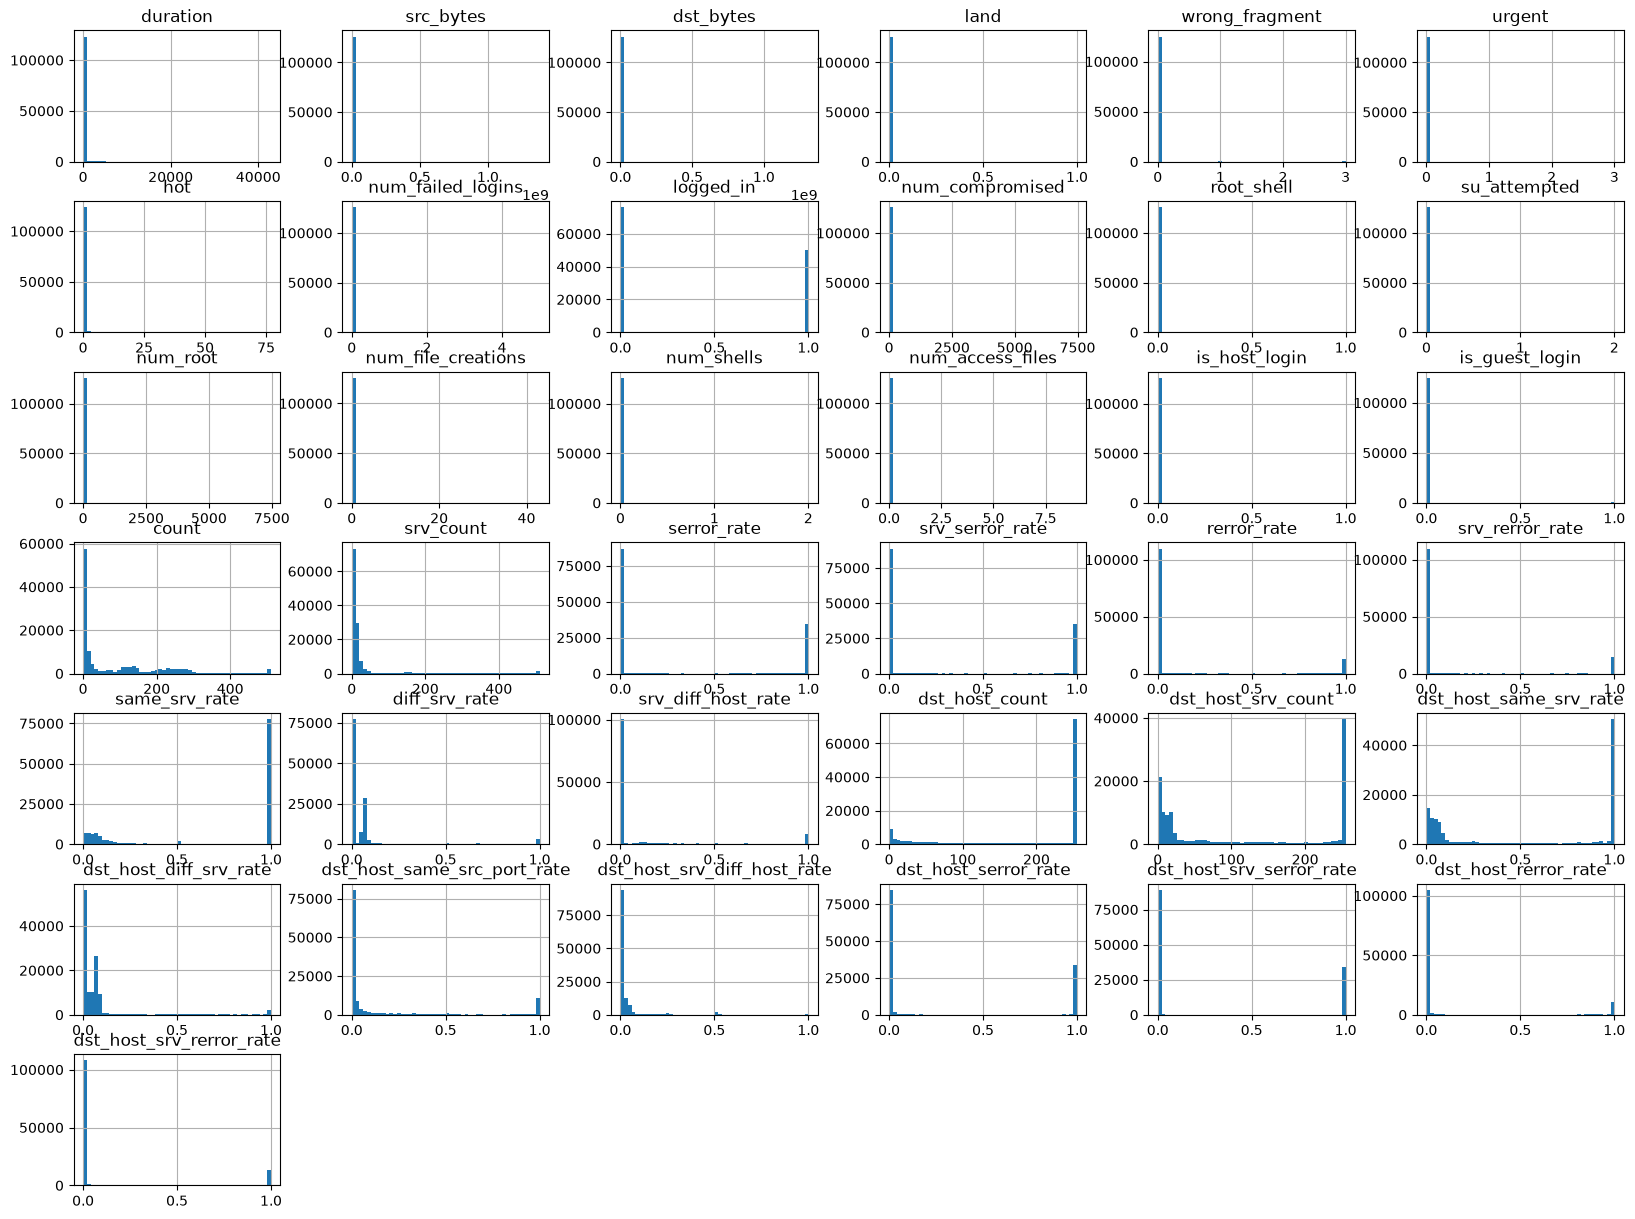

In [12]:
X_train.hist(bins = 50, figsize=(20, 15))

In [13]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>,
        <Axes: title={'center': '4'}>, <Axes: title={'center': '5'}>,
        <Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>],
       [<Axes: title={'center': '8'}>, <Axes: title={'center': '9'}>,
        <Axes: title={'center': '10'}>, <Axes: title={'center': '11'}>,
        <Axes: title={'center': '12'}>, <Axes: title={'center': '13'}>,
        <Axes: title={'center': '14'}>, <Axes: title={'center': '15'}>],
       [<Axes: title={'center': '16'}>, <Axes: title={'center': '17'}>,
        <Axes: title={'center': '18'}>, <Axes: title={'center': '19'}>,
        <Axes: title={'center': '20'}>, <Axes: title={'center': '21'}>,
        <Axes: title={'center': '22'}>, <Axes: title={'center': '23'}>],
       [<Axes: title={'center': '24'}>, <Axes: title={'center': '25'}>,
        <Axes: title={'center': '26'}>, <Axes: title={'center': '27'}>,

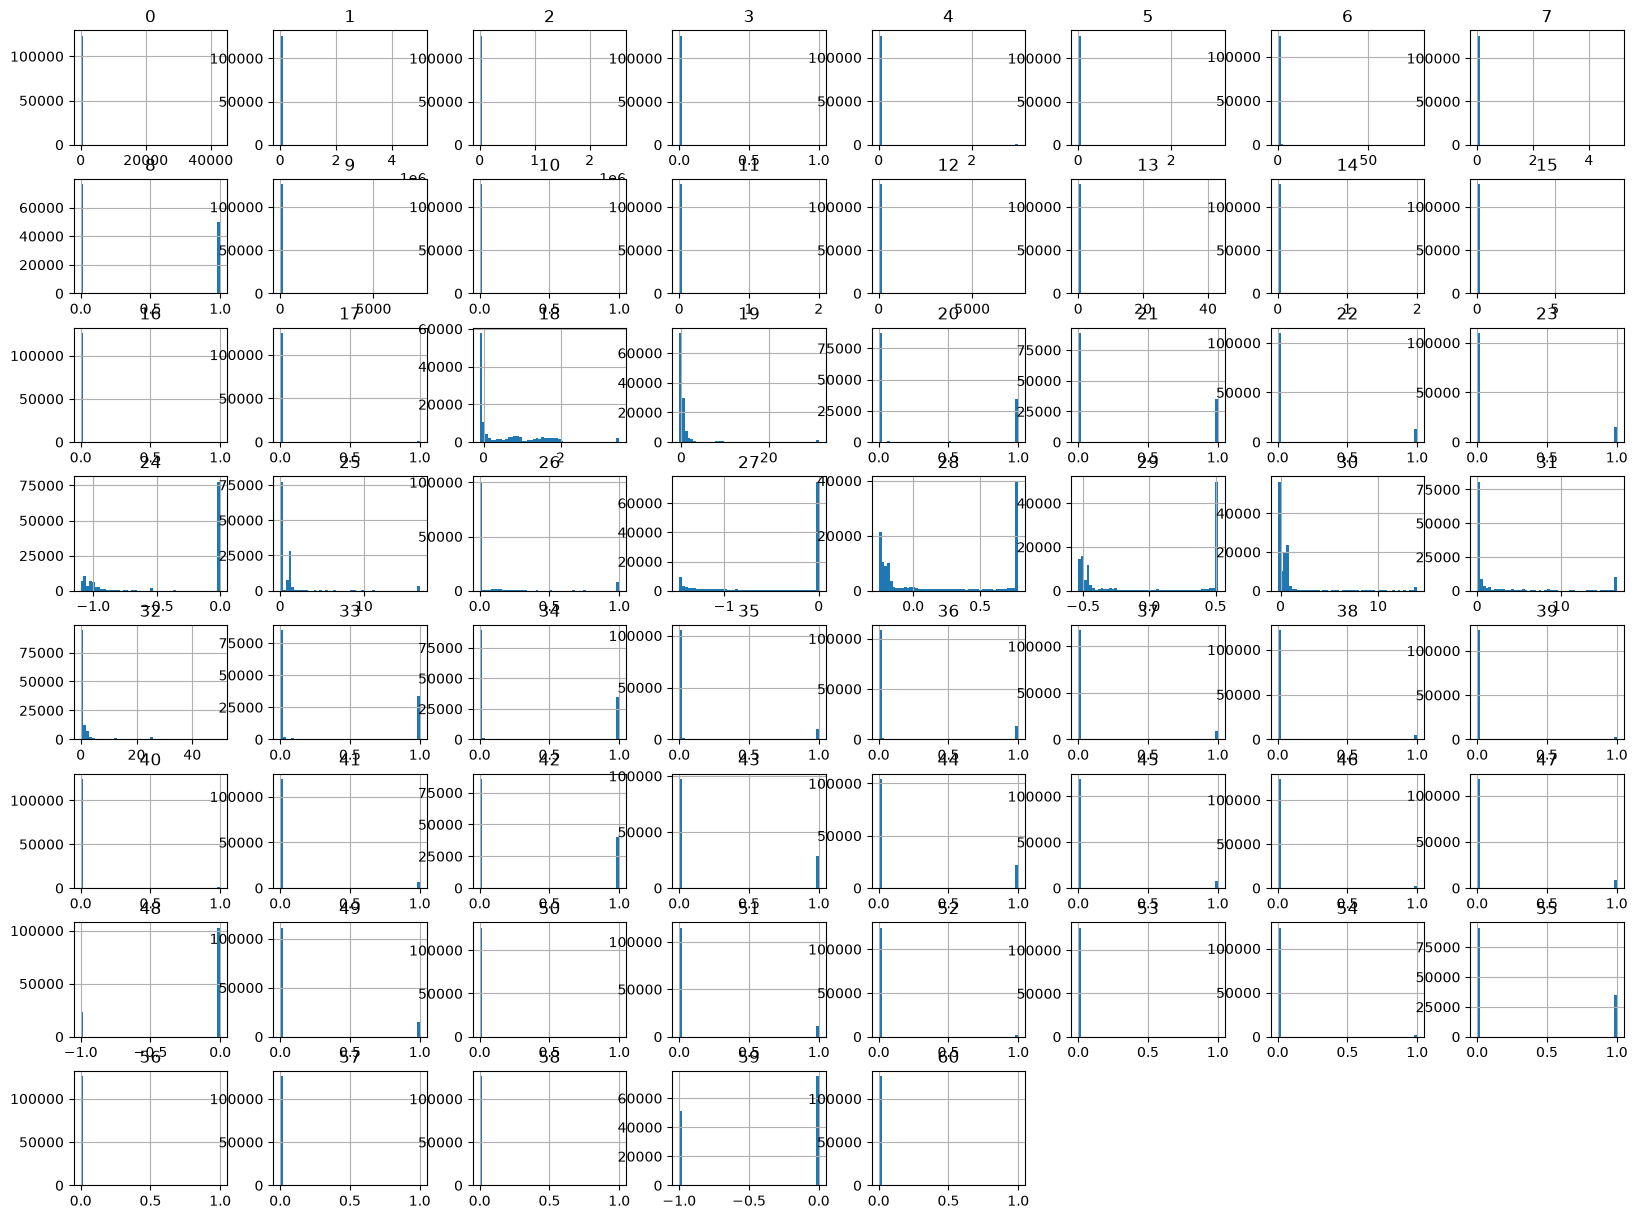

In [14]:
pd.DataFrame(X_train_scaled).hist(bins = 50, figsize=(20, 15))

In [15]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_binary)

C:\Users\learnmode\Desktop\projects_ml_cybersec\env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [16]:
y_pred = lr_model.predict(X_test_scaled)

print(classification_report(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.92      0.76      9711
           1       0.91      0.61      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.74     22544



In [17]:
#regresja sobie nie radzi, racall = 0.61

In [18]:
#Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train_binary)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test_binary, y_pred_rf))

              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



In [24]:
#w kdd test mamy nowe typy atakow ktore model rozpoznaje jako normalny ruch, musimy polaczyc dane i podzielic losowo

X_all = df_all_cleaned.drop(columns=['label', 'is_train'])
y_all = df_all_cleaned['label'].apply(lambda x: 0 if x == 'normal' else 1)

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

X_train_rand.shape

rf_rand = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_rand.fit(X_train_rand, y_train_rand)

y_pred_rand = rf_rand.predict(X_test_rand)
print(classification_report(y_test_rand, y_pred_rand))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15450
           1       1.00      0.99      1.00     14254

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



In [20]:
#waznosc cech z modelu

importances = rf_rand.feature_importances_
feature_names = X_train_rand.columns

print(importances)

[1.09281376e-02 1.55264275e-01 8.28674845e-02 2.09871478e-05
 2.15728392e-03 5.12746397e-05 1.08844417e-02 2.53900054e-03
 6.34408392e-02 5.71631293e-03 1.78228673e-04 3.82848799e-05
 3.65767886e-04 1.94809845e-04 1.20654923e-04 1.01449459e-04
 3.77177032e-05 1.83237129e-03 3.50571519e-02 1.13234144e-02
 1.36973387e-02 1.61073192e-02 9.46422424e-03 4.96785782e-03
 5.12524983e-02 2.28726875e-02 4.20517051e-03 1.48809486e-02
 7.02295875e-02 4.47545660e-02 4.01660725e-02 2.14210876e-02
 2.41722744e-02 1.42911707e-02 2.07886174e-02 2.27015019e-02
 7.97249310e-03 5.42963574e-03 8.88319105e-03 1.64127880e-02
 2.72025524e-03 6.13237275e-03 1.37997539e-02 9.67918865e-03
 1.16030342e-02 2.15162488e-03 4.58665085e-03 1.66019085e-02
 1.09439257e-02 9.15970418e-03 1.52855899e-05 1.65739729e-03
 5.88811325e-04 2.05404499e-05 2.86988658e-03 1.15112941e-02
 3.13466366e-04 6.88568261e-05 9.51823963e-05 7.75933715e-02
 9.65697678e-05]


C:\Users\learnmode\AppData\Local\Temp\ipykernel_19080\1182560156.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=forest_importances, palette='viridis')


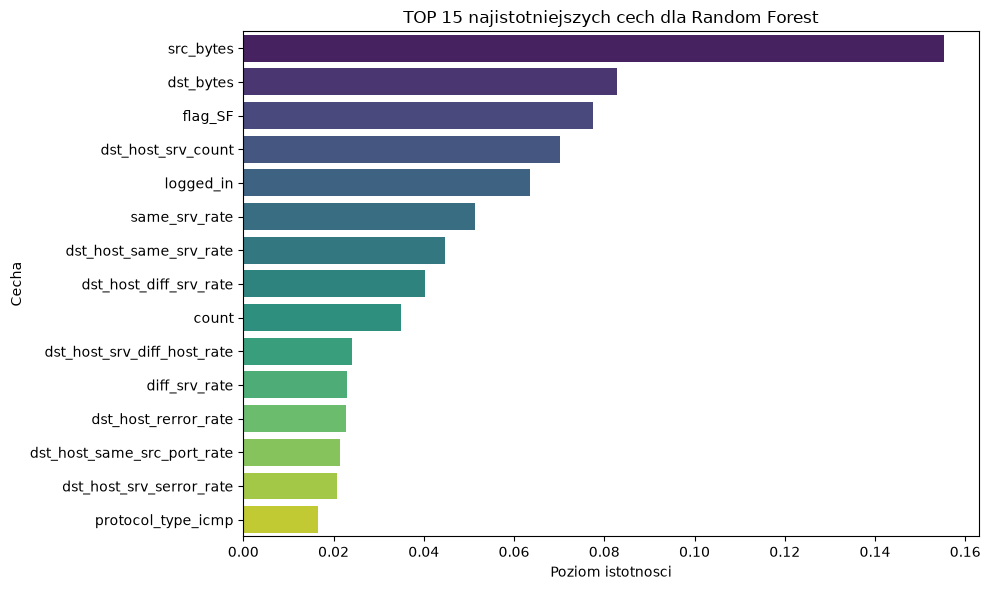

In [21]:
forest_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
forest_importances = forest_importances.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=forest_importances, palette='viridis')
plt.title('TOP 15 najistotniejszych cech dla Random Forest')
plt.xlabel('Poziom istotnosci')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

In [22]:
joblib.dump(rf_rand, 'nsl_kdd_random_forest.joblib')

joblib.dump(top_10_services, 'top_10_services.joblib')

joblib.dump(X_train_rand.columns.tolist(), 'model_columns.joblib')


print('Zapisano pliki...')

Zapisano pliki...
